# 02 — Exploratory Data Analysis

**Project:** *Self-Tracking Longitudinal Analysis: Lifestyle Factors & Academic Productivity*

This notebook covers the **EDA** stage:

1. Descriptive statistics
2. Productivity trend over the semester
3. Productivity by week type
4. Correlation heatmap
5. Scatter plots: all predictors vs productivity

All figures are saved under: `figures/`.

## 0) Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
os.makedirs('figures', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


## 1) Load Data

In [2]:
# ---- Real weekly data collected throughout the semester ----
# Semester started end of February
# Data collected up to Week 10 (May 2nd)
#
# Exam dates: April 5, 6 (week 7), April 19 (week 8)
# Enrichment: week_type derived from official academic calendar
data = {
    'week':       [1,    2,    3,    4,    5,    6,    7,        8,        9,    10   ],
    'week_type':  ['regular','regular','regular','regular','regular','regular','midterm','midterm','regular','regular'],
    'study_hours':[10,   10,   9,    10,   9,    10,   25,       25,       10,   9    ],
    'sleep_avg':  [7.2,  7.0,  7.1,  7.0,  7.2,  7.0,  6.0,      6.2,      7.0,  7.1  ],
    'stress_level':[5,   5,    5,    5,    5,    6,    9,        8,        6,    6    ],
    'motivation_level':[4, 4,  4,    3,    3,    3,    3,        3,        2,    2    ],
    'language_difficulty':[5, 5, 5,  5,    5,    5,    6,        6,        5,    5    ],
    'productivity_score':[58, 56, 57, 55,  54,   53,   43,       46,       52,   50   ]
}

df = pd.DataFrame(data)
print(f'Dataset: {df.shape[0]} weeks x {df.shape[1]} variables')
df


Dataset: 10 weeks x 8 variables


,week,week_type,study_hours,sleep_avg,stress_level,motivation_level,language_difficulty,productivity_score
0,1,regular,10,7.2,5,4,5,58
1,2,regular,10,7.0,5,4,5,56
2,3,regular,9,7.1,5,4,5,57
3,4,regular,10,7.0,5,3,5,55
4,5,regular,9,7.2,5,3,5,54
5,6,regular,10,7.0,6,3,5,53
6,7,midterm,25,6.0,9,3,6,43
7,8,midterm,25,6.2,8,3,6,46
8,9,regular,10,7.0,6,2,5,52
9,10,regular,9,7.1,6,2,5,50


## 2) Descriptive Statistics

In [3]:
numeric_cols = ['study_hours','sleep_avg','stress_level',
                'motivation_level','language_difficulty','productivity_score']
print('=== Descriptive Statistics ===')
print(df[numeric_cols].describe().round(2))
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Week Type Counts ===')
print(df['week_type'].value_counts())

=== Descriptive Statistics ===
       study_hours  sleep_avg  stress_level  motivation_level  \
count        10.00      10.00         10.00             10.00   
mean         12.70       6.88          6.00              3.10   
std           6.50       0.42          1.41              0.74   
min           9.00       6.00          5.00              2.00   
25%           9.25       7.00          5.00              3.00   
50%          10.00       7.00          5.50              3.00   
75%          10.00       7.10          6.00              3.75   
max          25.00       7.20          9.00              4.00   

       language_difficulty  productivity_score  
count                10.00               10.00  
mean                  5.20               52.40  
std                   0.42                4.84  
min                   5.00               43.00  
25%                   5.00               50.50  
50%                   5.00               53.50  
75%                   5.00              

## 3) Productivity Over the Semester

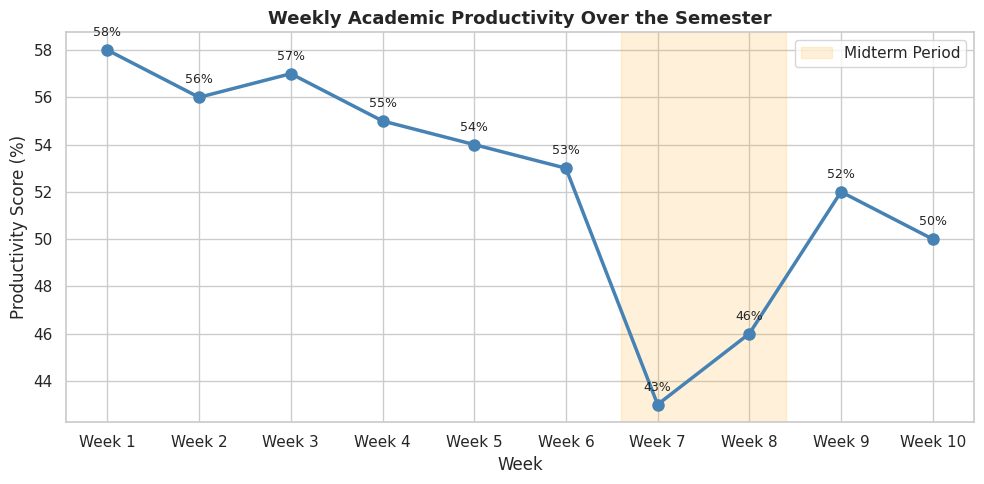

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['week'], df['productivity_score'], marker='o', color='steelblue', linewidth=2.5, markersize=8)
for _, row in df.iterrows():
    ax.annotate(f"{row['productivity_score']:.0f}%",
                xy=(row['week'], row['productivity_score']),
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=9)
midterm_weeks = df[df['week_type']=='midterm']['week']
ax.axvspan(midterm_weeks.min()-0.4, midterm_weeks.max()+0.4, alpha=0.15, color='orange', label='Midterm Period')
ax.set_title('Weekly Academic Productivity Over the Semester', fontsize=13, fontweight='bold')
ax.set_xlabel('Week'); ax.set_ylabel('Productivity Score (%)')
ax.set_xticks(df['week']); ax.set_xticklabels([f'Week {w}' for w in df['week']])
ax.legend(); plt.tight_layout()
plt.savefig('figures/productivity_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 4) Productivity by Week Type

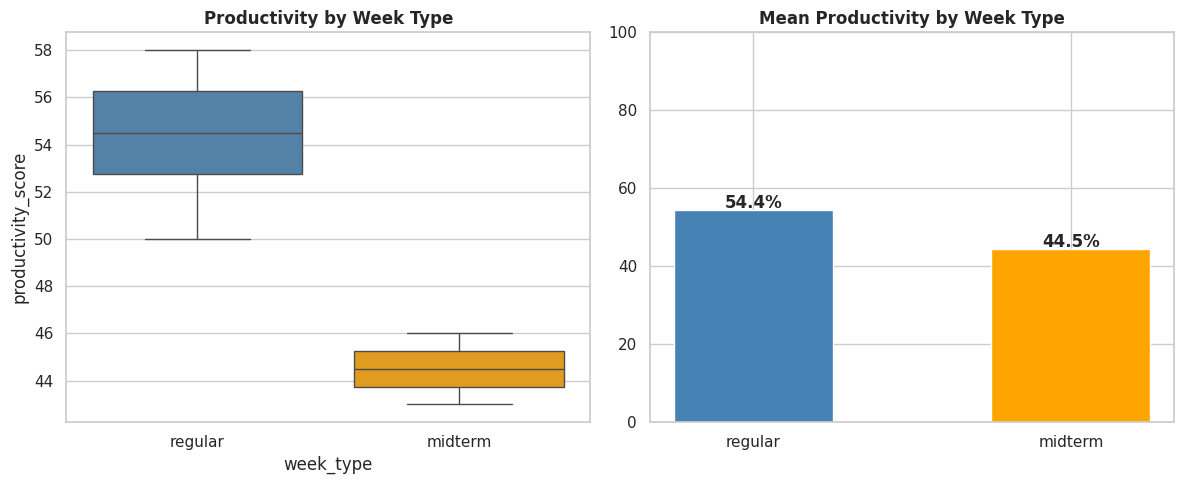

            mean   std  count
week_type                    
midterm    44.50  2.12      2
regular    54.38  2.67      8


In [5]:
palette = {'regular':'steelblue','midterm':'orange'}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='week_type', y='productivity_score', order=['regular','midterm'], palette=palette, ax=axes[0])
axes[0].set_title('Productivity by Week Type', fontweight='bold')
means = df.groupby('week_type')['productivity_score'].mean().reindex(['regular','midterm'])
bars = axes[1].bar(means.index, means.values, color=[palette[w] for w in means.index], edgecolor='white', width=0.5)
for bar, val in zip(bars, means.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Mean Productivity by Week Type', fontweight='bold'); axes[1].set_ylim(0, 100)
plt.tight_layout()
plt.savefig('figures/productivity_by_week_type.png', dpi=150, bbox_inches='tight')
plt.show()
print(df.groupby('week_type')['productivity_score'].agg(['mean','std','count']).round(2))

## 5) Correlation Heatmap

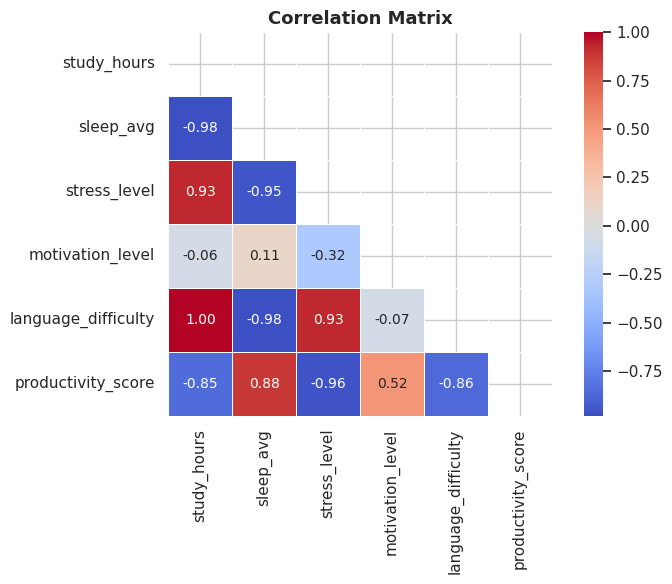

Correlations with Productivity Score:
sleep_avg              0.88
motivation_level       0.52
study_hours           -0.85
language_difficulty   -0.86
stress_level          -0.96
Name: productivity_score, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[numeric_cols].corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True,
            linewidths=0.5, mask=mask, ax=ax, fmt='.2f', annot_kws={'size':10})
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Correlations with Productivity Score:')
print(corr['productivity_score'].drop('productivity_score').sort_values(ascending=False))

## 6) Scatter Plots: Predictors vs Productivity

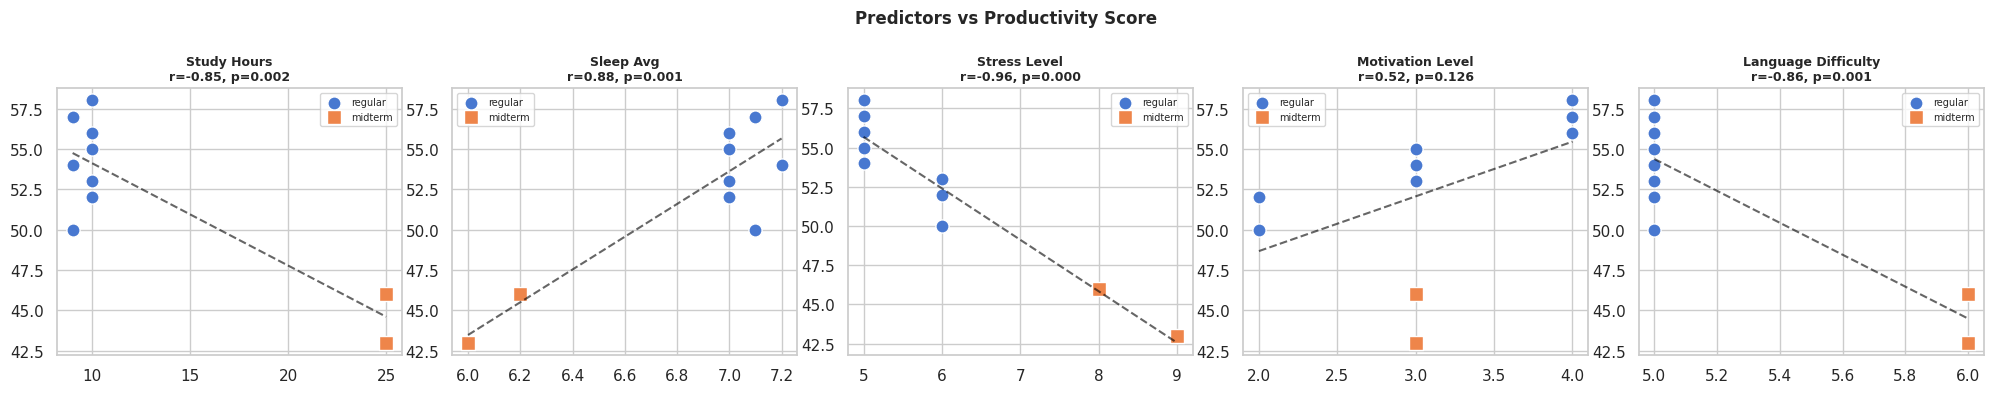

In [7]:
predictors = [('study_hours','steelblue'),('sleep_avg','seagreen'),
              ('stress_level','tomato'),('motivation_level','mediumpurple'),
              ('language_difficulty','darkorange')]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (col, color) in zip(axes, predictors):
    for wt, marker in [('regular','o'),('midterm','s')]:
        sub = df[df['week_type']==wt]
        ax.scatter(sub[col], sub['productivity_score'], label=wt, marker=marker, s=90, edgecolors='white')
    m, b = np.polyfit(df[col], df['productivity_score'], 1)
    x_l = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_l, m*x_l+b, color='black', linewidth=1.5, linestyle='--', alpha=0.6)
    r, p = stats.pearsonr(df[col], df['productivity_score'])
    ax.set_title(f'{col.replace("_"," ").title()}\nr={r:.2f}, p={p:.3f}', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
plt.suptitle('Predictors vs Productivity Score', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/scatter_predictors.png', dpi=150, bbox_inches='tight')
plt.show()